# 06 · Motor imagery: a first decoder

**ROBT613 · Brain–Computer Interfaces** | 90–120 min

## Goal
Decode imagined left versus right hand movement with spectral features and leave-one-run-out validation.

**Data:** MNE EEGBCI subject 1, imagery runs 4/8/12

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: ./mne_data


## Concepts and mathematics

Sensorimotor rhythms include mu (roughly 8–13 Hz) and beta (roughly 13–30 Hz) activity. Motor imagery can change their power; activity over contralateral sensorimotor cortex often desynchronizes. These are tendencies, not a guaranteed pattern for every participant. Eye, muscle and cue-related signals can also predict the task.

Band power integrates a PSD: $P_{c,[a,b]}=\int_a^b\hat P_c(f)df$. A feature $z_c=\log(P_c+\epsilon)$ reduces skew. Logistic regression maps $p(y=1|z)=\sigma(w^Tz+b)$ and minimizes cross-entropy plus a penalty on $w$. Standardization must learn its mean and scale from training data only.

Runs 4, 8 and 12 in PhysioNet EEGBCI all represent imagined left/right fist. Runs 6, 10 and 14 instead use hands/feet; mixing them under one T1/T2 label would change the task. We test transfer to a held-out run of the same participant, not to a new person.

## Load runs and preserve groups
Continuous filtering is performed independently within each run before epoching.

In [2]:
from mne.datasets import eegbci
runs = [4, 8, 12]  # ALL are imagined left versus right fist, not hands versus feet
parts, groups = [], []
for run in runs:
    paths = eegbci.load_data(1, [run], path=DATA_ROOT, update_path=False)
    raw_run = mne.io.read_raw_edf(paths[0], preload=True, verbose=False)
    eegbci.standardize(raw_run)
    raw_run.set_montage('standard_1005')
    raw_run.set_eeg_reference('average', projection=False)
    raw_run.filter(8, 30, fir_design='firwin')
    events, _ = mne.events_from_annotations(raw_run, event_id={'T1': 1, 'T2': 2})
    ep = mne.Epochs(raw_run, events, {'left': 1, 'right': 2}, tmin=0.5,
                    tmax=3.5, baseline=None, preload=True, picks='eeg',
                    reject_by_annotation=True)
    parts.append(ep)
    groups.extend([run] * len(ep))
epochs = mne.concatenate_epochs(parts)
X = epochs.get_data(copy=True)
y = epochs.events[:, 2] - 1
groups = np.asarray(groups)
print('Epochs:', X.shape, 'run counts:', pd.Series(groups).value_counts().to_dict())

/tmp/ipykernel_417820/2492561078.py:8: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw_run.set_montage('standard_1005')


/tmp/ipykernel_417820/2492561078.py:8: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw_run.set_montage('standard_1005')


Epochs: (45, 64, 481) run counts: {4: 15, 8: 15, 12: 15}


/tmp/ipykernel_417820/2492561078.py:8: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw_run.set_montage('standard_1005')
/tmp/ipykernel_417820/2492561078.py:17: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs = mne.concatenate_epochs(parts)


## Extract mu and beta power
Use C3, Cz and C4 to keep the first model interpretable; this channel set is declared in advance.

Feature matrix: (45, 6)


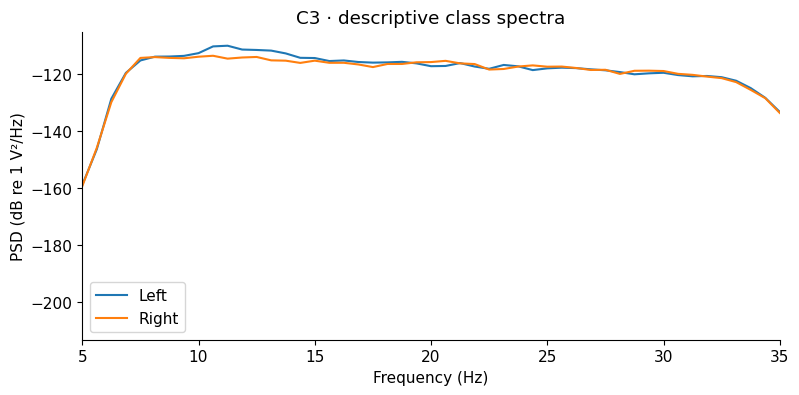

In [3]:
picks=[epochs.ch_names.index(ch) for ch in ['C3','Cz','C4']]
f,psd=signal.welch(X[:,picks,:],fs=epochs.info['sfreq'],nperseg=256,axis=-1)
features=np.concatenate([np.log(np.maximum(np.trapezoid(psd[:,:,(f>=a)&(f<=b)],f[(f>=a)&(f<=b)],axis=-1),1e-30))
                         for a,b in [(8,13),(13,30)]],axis=1)
print('Feature matrix:',features.shape)
fig,ax=plt.subplots()
for label,name in [(0,'Left'),(1,'Right')]:
    ax.plot(f,10*np.log10(psd[y==label,0].mean(0)),label=name)
ax.set(xlim=(5,35),xlabel='Frequency (Hz)',ylabel='PSD (dB re 1 V²/Hz)',title='C3 · descriptive class spectra')
ax.legend(); plt.show()

## Evaluate run transfer
Three folds are descriptive repeated measurements, not three independent participants.

In [4]:
model=make_pipeline(StandardScaler(),LogisticRegression(C=1,max_iter=1000,random_state=SEED))
cv=GroupKFold(n_splits=3)
result=cross_validate(model,features,y,groups=groups,cv=cv,
                      scoring=['balanced_accuracy','roc_auc'],return_train_score=False)
print(pd.DataFrame({k:v for k,v in result.items() if k.startswith('test_')}))
assert np.isfinite(result['test_balanced_accuracy']).all()

   test_balanced_accuracy  test_roc_auc
0                0.616071      0.767857
1                0.544643      0.446429
2                0.526786      0.660714


## Exercises and checks
1. Repeat with all EEG channels using the same held-out runs. What complexity changes?
2. Compare mu-only, beta-only and combined features using nested selection.
3. Explain why left/right hand movements are not the same labels as motor imagery.
4. Design a new-subject experiment and state its split unit.

## Next steps and sources
[EEGBCI dataset and run mapping](https://mne.tools/stable/generated/mne.datasets.eegbci.load_data.html) · [Logistic regression](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.